In [1]:
import os
import sys
import torch
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import polars as pl

helpers_path = os.path.abspath('/home/aegis/Titan1/NRAD/data/model_scripts')
sys.path.insert(0, helpers_path)
from Classifier_CW import Classifier_CW as Classifier

/home/aegis/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
selection = "ML"
dataset_path = f"Final_Dataset_{selection}"
model_path = f"Models_Extrapolation_{selection}_ver2"
config_path = "configs" 
os.makedirs(model_path, exist_ok=True)

device = torch.device("cpu")
print(f"Using device: {device}")

features_to_train = [
    'met_recalc_pt', 'ht', 
    'mjj', 'ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32'
]

N_ENSEMBLES = 10

Using device: cpu


### Training

In [3]:
train_model = True

if train_model:        
    USE_WEIGHTS = True       

    # =====================================================================
    # 2. MAIN TRAINING LOOP OVER CONFIGURED TASKS
    # =====================================================================

    print(f"\n{'='*70}")
    print(f" 🚀 PROCESSING: Reweight in the {selection} Selection")
    print(f"{'='*70}")
    
    # --- A. Split Datasets (The Anti-Leakage Step) ---
    mc_train = pd.read_parquet(f"{dataset_path}/CR_Dataset_Splits/MC_events_train.parquet")
    data_train = pd.read_parquet(f"{dataset_path}/CR_Dataset_Splits/DATA_events_train.parquet")
    
    print(f"MC Split   -> Train: {len(mc_train)}")
    print(f"Data Split -> Train: {len(data_train)}")

    # --- B. Prepare Arrays for PyTorch ---
    x_mc_train = mc_train[features_to_train].values
    x_data_train = data_train[features_to_train].values

    y_mc_train = np.zeros((x_mc_train.shape[0], 1))
    y_data_train = np.ones((x_data_train.shape[0], 1))

    input_x = np.vstack([x_data_train, x_mc_train])
    input_y = np.vstack([y_data_train, y_mc_train])

    # --- C. Handle Optional Weights ---
    if USE_WEIGHTS:
        print("Using sample weights for training.")
        w_data = np.ones((x_data_train.shape[0], 1))
        # Ensure 'final_weight' exists or fall back to 'raw_weights'
        weight_col = 'final_weight'
        w_mc = mc_train[weight_col].values.reshape(-1, 1)
        input_w = np.vstack([w_data, w_mc])
    else:
        print("Training WITHOUT sample weights.")
        input_w = None

    # --- D. Ensemble Training ---
    with open(f"{config_path}/reweight_physics.yml", 'r') as stream:
        params_rw = yaml.safe_load(stream)

    for i in range(N_ENSEMBLES):
        print(f"\n--- Training Ensemble {i+1}/{N_ENSEMBLES} ---")
        
        NN_rw = Classifier(
            n_inputs=len(features_to_train), 
            layers=params_rw.get("layers"), 
            learning_rate=0.0001, 
            device=device
        )

        current_seed = 42 + i*7

        # Tag the model with the run_name (e.g., "reweight_Combined_CRs_ens0")
        model_name = f"reweight_ens{i}"
        
        NN_rw.train(
            input_x=input_x, 
            input_y=input_y, 
            weights=input_w, 
            save_model=True, 
            batch_size=params_rw.get("batch_size"), 
            n_epochs=params_rw.get("n_epochs"), 
            model_name=model_name, 
            outdir=model_path,
            early_stop=True,
            seed=current_seed 
        )
print("\n🎉 Reweight training phase complete!")


 🚀 PROCESSING: Reweight in the ML Selection
MC Split   -> Train: 2542566
Data Split -> Train: 3843414
Using sample weights for training.

--- Training Ensemble 1/10 ---


 64%|======    | 32/50 [21:18<11:59, 39.97s/it]



--- Training Ensemble 2/10 ---


 60%|======    | 30/50 [20:19<13:32, 40.65s/it]



--- Training Ensemble 3/10 ---


...


--- Training Ensemble 9/10 ---


 52%|=====     | 26/50 [17:43<16:21, 40.91s/it]



--- Training Ensemble 10/10 ---


 32%|===       | 16/50 [11:12<23:50, 42.06s/it]


🎉 Reweight training phase complete!


### Loss Evaluation

In [4]:
loss_path = os.path.join(model_path, "loss_data")
print(f"Loss data read from: {loss_path}")

Loss data read from: Models_Extrapolation_ML_ver2/loss_data


In [5]:
all_train_losses = []
all_val_losses = []

for i in range(N_ENSEMBLES):
    model_name = f"reweight_ens{i}"
    loss_file = os.path.join(loss_path, f"{model_name}_loss.npz")
    
    if os.path.exists(loss_file):
        with np.load(loss_file) as loss_data:
            all_train_losses.append(loss_data['train_loss'])
            all_val_losses.append(loss_data['val_loss'])
        print(f"Loaded loss data for {model_name}")
    else:
        print(f"Warning: Loss file {loss_file} not found.")

# If no files were found, exit early
if not all_train_losses:
    raise FileNotFoundError("No loss files were found. Please check your path and model names.")


max_epochs = max(len(loss) for loss in all_train_losses)

padded_train_losses = []
padded_val_losses = []

for train_loss, val_loss in zip(all_train_losses, all_val_losses):
    pad_length = max_epochs - len(train_loss)
    
    # FORWARD FILLING (Recommended): Carries the final loss value forward
    padded_train_losses.append(np.pad(train_loss, (0, pad_length), mode='edge'))
    padded_val_losses.append(np.pad(val_loss, (0, pad_length), mode='edge'))
    
    # ALTERNATIVE (NaN Padding): If you prefer models to drop out of the average completely
    # padded_train_losses.append(np.pad(train_loss, (0, pad_length), constant_values=np.nan))
    # padded_val_losses.append(np.pad(val_loss, (0, pad_length), constant_values=np.nan))

# Convert to 2D numpy arrays
all_train_losses = np.array(padded_train_losses)
all_val_losses = np.array(padded_val_losses)

Loaded loss data for reweight_ens0
Loaded loss data for reweight_ens1
Loaded loss data for reweight_ens2
Loaded loss data for reweight_ens3
Loaded loss data for reweight_ens4
Loaded loss data for reweight_ens5
Loaded loss data for reweight_ens6
Loaded loss data for reweight_ens7
Loaded loss data for reweight_ens8
Loaded loss data for reweight_ens9


In [6]:
# ==========================================
# 4. Calculate Statistics
# ==========================================
# Note: If you switch to the NaN padding alternative above, 
# you MUST change np.mean to np.nanmean and np.std to np.nanstd here.
mean_train = np.mean(all_train_losses, axis=0)
std_train = np.std(all_train_losses, axis=0)

mean_val = np.mean(all_val_losses, axis=0)
std_val = np.std(all_val_losses, axis=0)

# Create the master x-axis
epochs_array = np.arange(max_epochs)

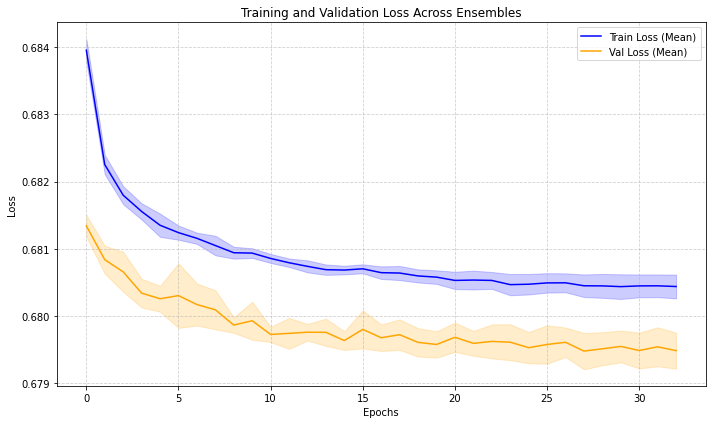

In [7]:
# ==========================================
# 5. Plotting
# ==========================================
plt.figure(figsize=(10, 6))

# Plot Training Loss (Blue)
plt.plot(epochs_array, mean_train, color='blue', label='Train Loss (Mean)')
plt.fill_between(
    epochs_array, 
    mean_train - std_train, 
    mean_train + std_train, 
    color='blue', 
    alpha=0.2
)

# Plot Validation Loss (Orange)
plt.plot(epochs_array, mean_val, color='orange', label='Val Loss (Mean)')
plt.fill_between(
    epochs_array, 
    mean_val - std_val, 
    mean_val + std_val, 
    color='orange', 
    alpha=0.2
)

# Formatting
plt.title('Training and Validation Loss Across Ensembles')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Display the plot
plt.tight_layout()
plt.show()

### Evaluation

In [8]:
from matplotlib import gridspec, ticker
from scipy.stats import chi2 as chi2_stat
from scipy.stats import wasserstein_distance

def plot_closure(region_name: str, df_mc: pl.DataFrame, df_data: pl.DataFrame, feature: str, force_log: bool = False):

    # Thesis/Publication styling settings
    plt.rcParams.update({
        'font.size': 14,
        'axes.labelsize': 16,
        'xtick.labelsize': 14,
        'ytick.labelsize': 14,
        'legend.fontsize': 12,
        'lines.linewidth': 1.5,
        'xtick.direction': 'in',
        'ytick.direction': 'in',
        'xtick.top': True,
        'ytick.right': True,
        'axes.formatter.use_mathtext': True,
        'axes.linewidth': 1.2,
        'hatch.linewidth': 0.5 # Thinner hatch lines look cleaner
    })
    
    pretty_labels = {
        'ht': r'$H_{T}$ [GeV]',
        'met_recalc_pt': r'$E_{T}^{\text{miss}}$ [GeV]',
        'met': r'$E_{T}^{\text{miss}}$ [GeV]', 
        'mjj': r'$m_{jj}$ [GeV]',
        'ljet1_tau21': r'Leading jet $\tau_{21}$',
        'ljet1_tau32': r'Leading jet $\tau_{32}$',
        'ljet2_tau21': r'Subleading jet $\tau_{21}$',
        'ljet2_tau32': r'Subleading jet $\tau_{32}$'
    }
    
    log_variables = ['ht', 'met_recalc_pt', 'met', 'mjj']
    use_log = force_log or any(log_var in feature.lower() for log_var in log_variables)
    
    # Extract arrays
    data_arr = df_data.get_column(feature).drop_nulls().to_numpy()
    mc_arr = df_mc.get_column(feature).drop_nulls().to_numpy()
    
    if len(data_arr) == 0:
        print(f"Skipping {feature} - No valid target data.")
        return
        
    # Extract Weights
    data_weight_col = "final_weight" if "final_weight" in df_data.columns else ("raw_weights" if "raw_weights" in df_data.columns else None)
    data_weights = df_data.get_column(data_weight_col).to_numpy() if data_weight_col else np.ones_like(data_arr)
    
    mc_weight_col = "final_weight"
    raw_weights_mc = df_mc.get_column(mc_weight_col).to_numpy() if mc_weight_col else np.ones_like(mc_arr)
    
    # Setup Figure Layout
    fig = plt.figure(figsize=(8, 8))
    gs = gridspec.GridSpec(2, 1, height_ratios=[3.5, 1], hspace=0.08)
    
    ax_main = fig.add_subplot(gs[0])
    ax_ratio = fig.add_subplot(gs[1], sharex=ax_main)
    
    # Dynamic binning spanning all distributions
    # combined_arr = np.concatenate([data_arr, mc_arr])
    # bins = np.histogram_bin_edges(combined_arr, bins=15)
    # bin_centers = (bins[:-1] + bins[1:]) / 2
    # bin_widths = np.diff(bins)

    # bins = np.arange(-2.5, 2.6, 0.25)
    bins = np.arange(-3.0, 3.0, 0.25)
    # Note: np.linspace(-2.5, 2.5, 51) also works and avoids floating-point quirks
    
    bin_centers = (bins[:-1] + bins[1:]) / 2
    bin_widths = np.diff(bins)

    # ==========================================
    # 1. MAIN PANEL CALCULATIONS & PLOTTING
    # ==========================================
    
    # --- Target Data (Black Points) ---
    counts_data, _ = np.histogram(data_arr, bins=bins, weights=data_weights)
    sumw2_data, _ = np.histogram(data_arr, bins=bins, weights=data_weights**2)
    data_errors = np.sqrt(sumw2_data)
    
    ax_main.errorbar(bin_centers, counts_data, yerr=data_errors, 
                     fmt='ko', label='Target Data', zorder=10, capsize=0, markersize=5)
                     
    # --- Nominal MC (Red Step Line) ---
    counts_mc_raw, _ = np.histogram(mc_arr, bins=bins, weights=raw_weights_mc)
    sumw2_mc_raw, _ = np.histogram(mc_arr, bins=bins, weights=raw_weights_mc**2)
    mc_err_raw = np.sqrt(sumw2_mc_raw)
    
    ax_main.hist(mc_arr, bins=bins, weights=raw_weights_mc, histtype='step', 
                 color='#e31a1c', linewidth=2, linestyle='--', label='Nominal MC')
                 
    ax_main.bar(bin_centers, 2 * mc_err_raw, bottom=counts_mc_raw - mc_err_raw, width=bin_widths,
                color='none', edgecolor='gray', hatch='////', linewidth=0,
                alpha=0.5, zorder=5, label='Stat. Unc.')
    
    # --- ML Reweighted MC (Blue Filled) ---
    ml_weights_mean = df_mc.get_column("reweight_weights_mean").to_numpy()
    reweighted_mc_weights = raw_weights_mc * ml_weights_mean
    
    # Nominal Yields & Stat Variance
    counts_mc_ml, _ = np.histogram(mc_arr, bins=bins, weights=reweighted_mc_weights)
    sumw2_mc_ml, _ = np.histogram(mc_arr, bins=bins, weights=reweighted_mc_weights**2)
    
    # Ensemble (Systematic) Variance Calculation
    ensemble_cols = [col for col in df_mc.columns if col.startswith('reweight_weights_ens')]
    ensemble_yields = []
    
    for col in ensemble_cols:
        ens_weights = raw_weights_mc * df_mc.get_column(col).to_numpy()
        y, _ = np.histogram(mc_arr, bins=bins, weights=ens_weights)
        ensemble_yields.append(y)
        
    ensemble_yields = np.array(ensemble_yields) 
    ensemble_variance = np.var(ensemble_yields, axis=0, ddof=1) 
    
    # Total Combined Variance (Stat + Syst)
    total_var_mc_ml = sumw2_mc_ml + ensemble_variance
    total_err_mc_ml = np.sqrt(total_var_mc_ml)
    
    ax_main.hist(mc_arr, bins=bins, weights=reweighted_mc_weights, histtype='stepfilled', 
                 color='#1f78b4', alpha=0.3, edgecolor='#1f78b4', label='Reweighted MC')
                 
    ax_main.bar(bin_centers, 2 * total_err_mc_ml, bottom=counts_mc_ml - total_err_mc_ml, width=bin_widths,
                color='none', edgecolor='#1f78b4', hatch='\\\\\\\\', linewidth=0,
                alpha=0.3, zorder=6, label='ML + Stat Unc.')

    # ==========================================
    # METRICS CALCULATION
    # ==========================================
    std_data = np.std(data_arr) if len(data_arr) > 0 else 1.0
    c_data_clean = np.clip(counts_data, 0, None)
    
    w1_nom = wasserstein_distance(bin_centers, bin_centers, u_weights=c_data_clean, v_weights=np.clip(counts_mc_raw, 0, None)) / std_data
    w1_rw  = wasserstein_distance(bin_centers, bin_centers, u_weights=c_data_clean, v_weights=np.clip(counts_mc_ml, 0, None)) / std_data

    def get_chi2_pval(c_target, c_pred, s2_target, s2_pred):
        mask = (c_target > 0) | (c_pred > 0)
        tot_var = s2_target[mask] + s2_pred[mask]
        valid = tot_var > 0
        chi2_val = np.sum((c_target[mask][valid] - c_pred[mask][valid])**2 / tot_var[valid])
        ndf = np.sum(valid) - 1 
        if ndf < 1: ndf = 1
        p_val = chi2_stat.sf(chi2_val, ndf)
        return chi2_val, ndf, p_val

    chi2_nom, ndf_nom, p_nom = get_chi2_pval(counts_data, counts_mc_raw, sumw2_data, sumw2_mc_raw)
    chi2_rw, ndf_rw, p_rw = get_chi2_pval(counts_data, counts_mc_ml, sumw2_data, total_var_mc_ml) # Updated to total_var

    print(f"Metrics for {feature} in {region_name}:")
    print(f"  Nominal MC -> chi2/ndf: {chi2_nom:.2f}/{ndf_nom} (p={p_nom:.4f}) | Norm W1: {w1_nom:.4f}")
    print(f"  Reweighted -> chi2/ndf: {chi2_rw:.2f}/{ndf_rw} (p={p_rw:.4f}) | Norm W1: {w1_rw:.4f}")
    print("-" * 70)

    # --- MAIN PANEL FORMATTING ---
    max_counts = max(
        np.max(counts_data) + np.max(data_errors) if len(counts_data) > 0 else 0,
        np.max(counts_mc_raw + mc_err_raw) if len(counts_mc_raw) > 0 else 0,
        np.max(counts_mc_ml + total_err_mc_ml) if len(counts_mc_ml) > 0 else 0,
    )
    
    if use_log:
        ax_main.set_yscale('log')
        ax_main.set_ylim(0.1, max_counts * 1000)
    else:
        ax_main.set_ylim(0, max_counts * 1.55)
        ax_main.yaxis.set_minor_locator(ticker.AutoMinorLocator())
        
    ax_main.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax_main.set_ylabel("Events / Bin")
    plt.setp(ax_main.get_xticklabels(), visible=False)
    
    textstr = f"{region_name} selection\nClosure Test\n" + r"$\sqrt{s} = 13$ TeV"
    ax_main.text(0.04, 0.94, textstr, transform=ax_main.transAxes, fontsize=14, verticalalignment='top')
                 
    handles, loc_labels = ax_main.get_legend_handles_labels()
    if "Target Data" in loc_labels:
        idx = loc_labels.index("Target Data")
        handles.insert(0, handles.pop(idx))
        loc_labels.insert(0, loc_labels.pop(idx))
    ax_main.legend(handles, loc_labels, loc='upper right', frameon=False, ncol=2)
    
    # ==========================================
    # 2. RATIO PANEL (Clean Visualization)
    # ==========================================
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio_raw = counts_data / counts_mc_raw
        ratio_rw  = counts_data / counts_mc_ml
        
        # Numerator Errors (Data Stat ONLY on the markers)
        ratio_raw_data_err = np.where(counts_mc_raw > 0, data_errors / counts_mc_raw, 0)
        ratio_rw_data_err  = np.where(counts_mc_ml > 0, data_errors / counts_mc_ml, 0)
        
        # Denominator Errors (Prediction fractional error for the bands)
        rel_err_raw = np.where(counts_mc_raw > 0, np.sqrt(sumw2_mc_raw) / counts_mc_raw, 0)
        rel_err_rw  = np.where(counts_mc_ml > 0, total_err_mc_ml / counts_mc_ml, 0) 

        # Mask invalid values
        ratio_raw = np.where(counts_mc_raw > 0, ratio_raw, np.nan)
        ratio_rw = np.where(counts_mc_ml > 0, ratio_rw, np.nan)

    ax_ratio.axhline(1.0, color='black', linestyle='-', linewidth=1.0, zorder=1)

    # Plot Nominal MC Stat Uncertainty band around 1.0
    ax_ratio.bar(bin_centers, 2 * rel_err_raw, bottom=1.0 - rel_err_raw, width=bin_widths,
                 color='none', edgecolor='#e31a1c', hatch='////', linewidth=0, 
                 alpha=0.4, zorder=2, label='Nominal Stat')

    # Plot Reweighted MC Total Uncertainty (Stat + Syst) band around 1.0
    ax_ratio.bar(bin_centers, 2 * rel_err_rw, bottom=1.0 - rel_err_rw, width=bin_widths,
                 color='#1f78b4', edgecolor='none', 
                 alpha=0.25, zorder=3, label='Reweight Tot')
    
    # Plot Nominal Ratio (Red Open Circles)
    ax_ratio.errorbar(bin_centers, ratio_raw, yerr=ratio_raw_data_err, fmt='o', 
                      color='#e31a1c', markerfacecolor='white', markeredgewidth=1.5, 
                      capsize=0, markersize=6, zorder=10)
                      
    # Plot ML Reweighted Ratio (Blue Filled Circles)
    ax_ratio.errorbar(bin_centers, ratio_rw, yerr=ratio_rw_data_err, fmt='o', 
                      color='#1f78b4', capsize=0, markersize=5, zorder=11)

    # --- RATIO PANEL FORMATTING ---
    x_label = pretty_labels.get(feature, feature)
    ax_ratio.set_xlabel(x_label)
    ax_ratio.set_ylabel("Data / Pred")
    
    ax_ratio.set_ylim(0.5, 1.5) 
    ax_ratio.set_yticks([0.6, 0.8, 1.0, 1.2, 1.4])
    
    ax_ratio.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax_ratio.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax_ratio.legend(loc='upper right', fontsize=10, frameon=False, ncol=2)
    
    fig.align_ylabels((ax_main, ax_ratio))

    plt.show()
    plt.close(fig)

In [9]:
def regularize_weights(weights, sigma=3.0):
        mean_w = np.mean(weights)
        std_w = np.std(weights)
        upper_bound = mean_w + (sigma * std_w)
        return np.clip(weights, a_min=0, a_max=upper_bound)


def reweight_weights(model, df_mc_pd, feature_list, ensemble_idx):
    x_test_mc = df_mc_pd[feature_list].values
    w_prob = model.evaluation(x_test_mc)
    w_prob = np.clip(w_prob, a_min = 1e-7, a_max = 1 - 1e-7)
    w = (w_prob / (1 - w_prob)).flatten()

    w_reg = regularize_weights(w, sigma=3.0)
    
    df_mc_pd[f'reweight_weights_ens{ensemble_idx}'] = w_reg

    return df_mc_pd    

def aggregate_ensemble_weights(df, n_ensembles):
    """Calculates the nominal physics weight and the shape uncertainty."""
    weight_cols = [f'reweight_weights_ens{i}' for i in range(n_ensembles)]
    
    df['reweight_nominal'] = df[weight_cols].mean(axis=1)
    df['reweight_uncert'] = df[weight_cols].std(axis=1)
    
    return df

In [10]:
# Direct load into Pandas
mc_cr = pd.read_parquet(f"{dataset_path}/CR_Dataset_Splits/MC_events_test.parquet")
mc_sr = pd.read_parquet(f"{dataset_path}/MC_SR_clean.parquet")

print(f"CR MC Split -> Test: {len(mc_cr)}")
print(f"SR MC Split -> Test: {len(mc_sr)}")

# 1. Apply to Control Region
print("\nApplying models to Control Region...")
for i in range(N_ENSEMBLES):
    model_name = f"reweight_ens{i}"
    model_file = os.path.join(model_path, f"{model_name}.pt")
    
    if os.path.exists(model_file):
        model = torch.load(model_file, map_location=device, weights_only=False)
        mc_cr = reweight_weights(model, mc_cr, features_to_train, i)
        
mc_cr = aggregate_ensemble_weights(mc_cr, N_ENSEMBLES)
print("CR aggregation complete. 'reweight_nominal' and 'reweight_uncert' added.")

# 2. Apply to Signal Region
print("\nApplying models to Signal Region...")
for i in range(N_ENSEMBLES):
    model_name = f"reweight_ens{i}"
    model_file = os.path.join(model_path, f"{model_name}.pt")
    
    if os.path.exists(model_file):
        model = torch.load(model_file, map_location=device, weights_only=False)
        mc_sr = reweight_weights(model, mc_sr, features_to_train, i)
        
mc_sr = aggregate_ensemble_weights(mc_sr, N_ENSEMBLES)
print("SR aggregation complete. 'reweight_nominal' and 'reweight_uncert' added.")

CR MC Split -> Test: 635642
SR MC Split -> Test: 528846

Applying models to Control Region...
CR aggregation complete. 'reweight_nominal' and 'reweight_uncert' added.

Applying models to Signal Region...
SR aggregation complete. 'reweight_nominal' and 'reweight_uncert' added.


#### Control Region

In [11]:
mc_test = pl.read_parquet(f"{dataset_path}/CR_Dataset_Splits/MC_events_test.parquet").to_pandas()
data_test = pl.read_parquet(f"{dataset_path}/CR_Dataset_Splits/DATA_events_test.parquet").to_pandas()

print(f"CR MC Split   -> Test: {len(mc_test)}")
print(f"CR Data Split -> Test: {len(data_test)}")

CR MC Split   -> Test: 635642
CR Data Split -> Test: 960854


In [12]:
for i in range(N_ENSEMBLES):
    model_name = f"reweight_ens{i}"
    model_file = os.path.join(model_path, f"{model_name}.pt")
    
    if os.path.exists(model_file):
        print(f"\nApplying {model_name} to reweight MC datasets...")
        model = torch.load(model_file, map_location=device, weights_only=False)
        mc_test = reweight_weights(model, mc_test, features_to_train, i)
    else:
        print(f"Warning: Model file {model_file} not found. Skipping this ensemble.")

mc_test["reweight_weights_mean"] = mc_test[[f'reweight_weights_ens{i}' for i in range(N_ENSEMBLES)]].mean(axis=1)
mc_test["reweight_weights_std"] = mc_test[[f'reweight_weights_ens{i}' for i in range(N_ENSEMBLES)]].std(axis=1)



Applying reweight_ens0 to reweight MC datasets...

Applying reweight_ens1 to reweight MC datasets...

Applying reweight_ens2 to reweight MC datasets...

Applying reweight_ens3 to reweight MC datasets...

Applying reweight_ens4 to reweight MC datasets...

Applying reweight_ens5 to reweight MC datasets...

Applying reweight_ens6 to reweight MC datasets...

Applying reweight_ens7 to reweight MC datasets...

Applying reweight_ens8 to reweight MC datasets...

Applying reweight_ens9 to reweight MC datasets...



Generating closure plot for feature: met_recalc_pt
Metrics for met_recalc_pt in CR:
  Nominal MC -> chi2/ndf: 3389.69/6 (p=0.0000) | Norm W1: 0.1395
  Reweighted -> chi2/ndf: 76.10/6 (p=0.0000) | Norm W1: 0.0368
----------------------------------------------------------------------


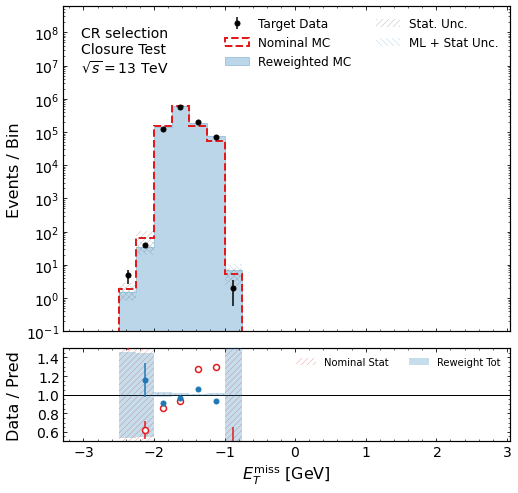


Generating closure plot for feature: ht
Metrics for ht in CR:
  Nominal MC -> chi2/ndf: 1353.86/13 (p=0.0000) | Norm W1: 0.0417
  Reweighted -> chi2/ndf: 241.46/19 (p=0.0000) | Norm W1: 0.0162
----------------------------------------------------------------------


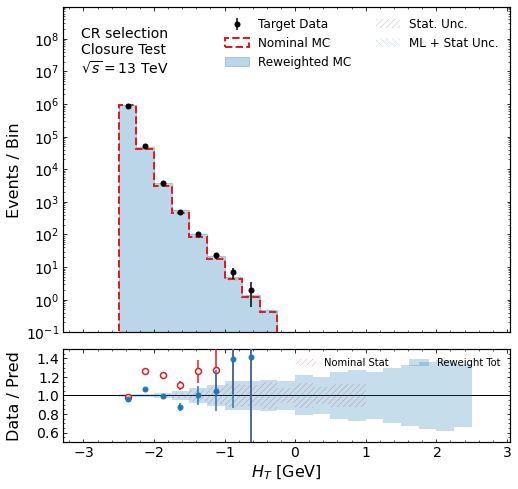


Generating closure plot for feature: mjj
Metrics for mjj in CR:
  Nominal MC -> chi2/ndf: 224.68/14 (p=0.0000) | Norm W1: 0.0502
  Reweighted -> chi2/ndf: 107.31/19 (p=0.0000) | Norm W1: 0.0318
----------------------------------------------------------------------


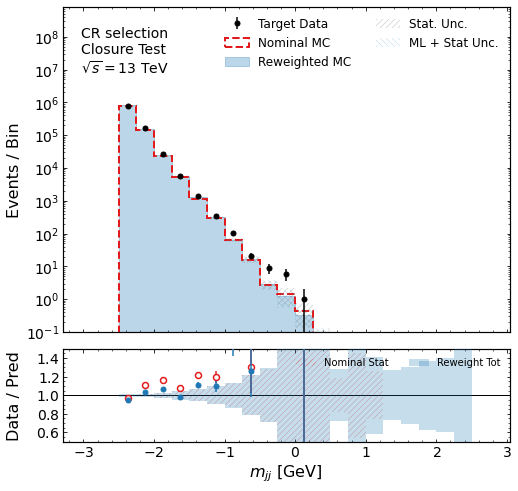


Generating closure plot for feature: ljet1_tau21
Metrics for ljet1_tau21 in CR:
  Nominal MC -> chi2/ndf: 466.19/19 (p=0.0000) | Norm W1: 0.0853
  Reweighted -> chi2/ndf: 35.45/19 (p=0.0123) | Norm W1: 0.0062
----------------------------------------------------------------------


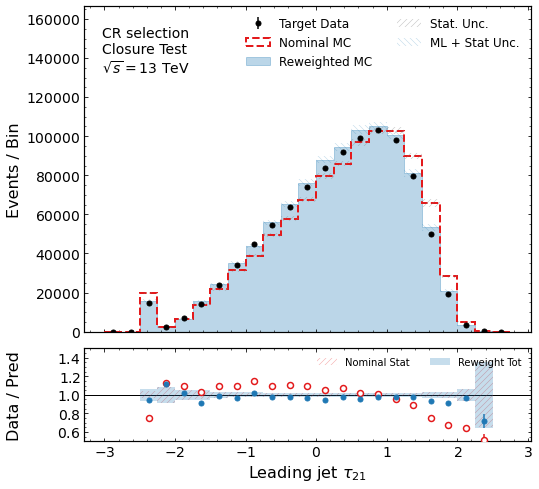


Generating closure plot for feature: ljet1_tau32
Metrics for ljet1_tau32 in CR:
  Nominal MC -> chi2/ndf: 651.29/19 (p=0.0000) | Norm W1: 0.0801
  Reweighted -> chi2/ndf: 73.43/19 (p=0.0000) | Norm W1: 0.0174
----------------------------------------------------------------------


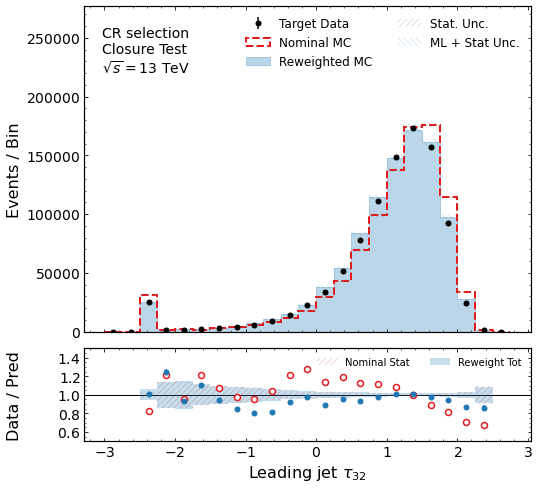


Generating closure plot for feature: ljet2_tau21
Metrics for ljet2_tau21 in CR:
  Nominal MC -> chi2/ndf: 712.69/19 (p=0.0000) | Norm W1: 0.1211
  Reweighted -> chi2/ndf: 42.04/19 (p=0.0017) | Norm W1: 0.0072
----------------------------------------------------------------------


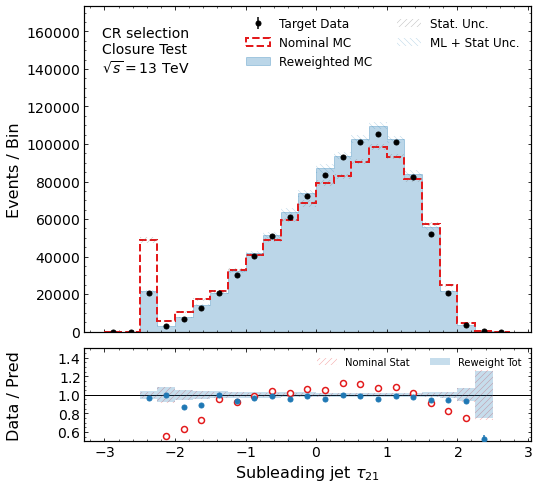


Generating closure plot for feature: ljet2_tau32
Metrics for ljet2_tau32 in CR:
  Nominal MC -> chi2/ndf: 1137.42/19 (p=0.0000) | Norm W1: 0.2167
  Reweighted -> chi2/ndf: 65.07/19 (p=0.0000) | Norm W1: 0.0147
----------------------------------------------------------------------


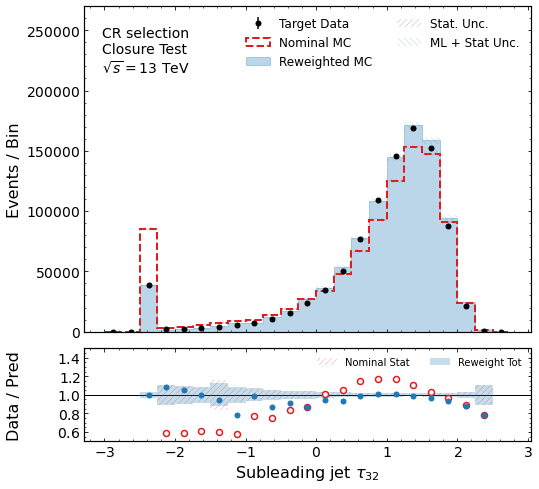

In [13]:
df_data_cr = pl.from_pandas(data_test)
df_mc_cr = pl.from_pandas(mc_test)

for feature in features_to_train:
    print(f"\nGenerating closure plot for feature: {feature}")
    plot_closure("CR", df_mc_cr, df_data_cr, feature)

#### Signal Region

In [14]:
mc_sr = pl.read_parquet(f"{dataset_path}/MC_SR_clean.parquet").to_pandas()
data_sr = pl.read_parquet(f"{dataset_path}/DATA_SR_clean.parquet").to_pandas()
print(f"SR MC Split   -> Test: {len(mc_sr)}")
print(f"SR Data Split -> Test: {len(data_sr)}")

SR MC Split   -> Test: 528846
SR Data Split -> Test: 188757


In [15]:
for i in range(N_ENSEMBLES):
    model_name = f"reweight_ens{i}"
    model_file = os.path.join(model_path, f"{model_name}.pt")
    
    if os.path.exists(model_file):
        print(f"\nApplying {model_name} to reweight SR datasets...")
        model = torch.load(model_file, map_location=device, weights_only=False)
        mc_sr = reweight_weights(model, mc_sr, features_to_train, i)
    else:
        print(f"Warning: Model file {model_file} not found. Skipping this ensemble.")
    
mc_sr["reweight_weights_mean"] = mc_sr[[f'reweight_weights_ens{i}' for i in range(N_ENSEMBLES)]].mean(axis=1)
mc_sr["reweight_weights_std"] = mc_sr[[f'reweight_weights_ens{i}' for i in range(N_ENSEMBLES)]].std(axis=1)




Applying reweight_ens0 to reweight SR datasets...

Applying reweight_ens1 to reweight SR datasets...

Applying reweight_ens2 to reweight SR datasets...

Applying reweight_ens3 to reweight SR datasets...

Applying reweight_ens4 to reweight SR datasets...

Applying reweight_ens5 to reweight SR datasets...

Applying reweight_ens6 to reweight SR datasets...

Applying reweight_ens7 to reweight SR datasets...

Applying reweight_ens8 to reweight SR datasets...

Applying reweight_ens9 to reweight SR datasets...



Generating closure plot for feature: met_recalc_pt
Metrics for met_recalc_pt in SR:
  Nominal MC -> chi2/ndf: 47.23/14 (p=0.0000) | Norm W1: 0.0043
  Reweighted -> chi2/ndf: 2008.63/14 (p=0.0000) | Norm W1: 0.1700
----------------------------------------------------------------------


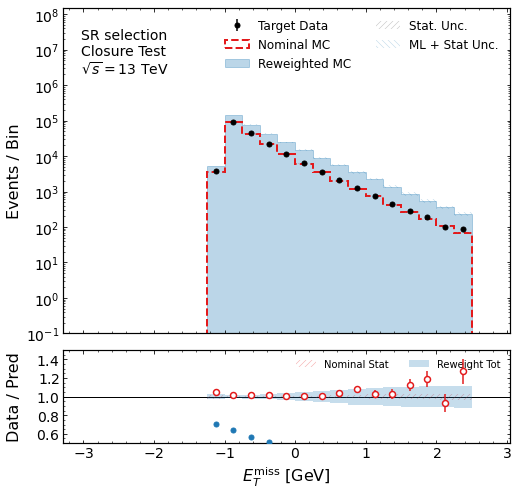


Generating closure plot for feature: ht
Metrics for ht in SR:
  Nominal MC -> chi2/ndf: 38.06/5 (p=0.0000) | Norm W1: 0.0083
  Reweighted -> chi2/ndf: 932.29/5 (p=0.0000) | Norm W1: 0.1472
----------------------------------------------------------------------


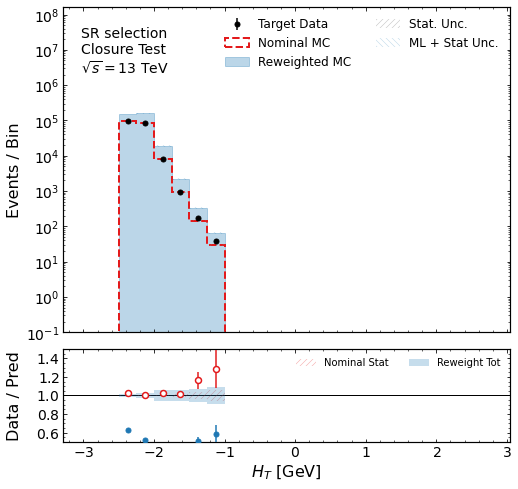


Generating closure plot for feature: mjj
Metrics for mjj in SR:
  Nominal MC -> chi2/ndf: 391.35/12 (p=0.0000) | Norm W1: 0.0635
  Reweighted -> chi2/ndf: 1305.83/12 (p=0.0000) | Norm W1: 0.0776
----------------------------------------------------------------------


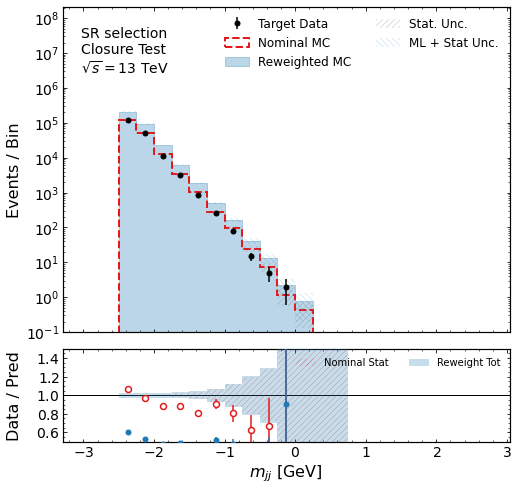


Generating closure plot for feature: ljet1_tau21
Metrics for ljet1_tau21 in SR:
  Nominal MC -> chi2/ndf: 791.97/20 (p=0.0000) | Norm W1: 0.0555
  Reweighted -> chi2/ndf: 4004.26/20 (p=0.0000) | Norm W1: 0.0160
----------------------------------------------------------------------


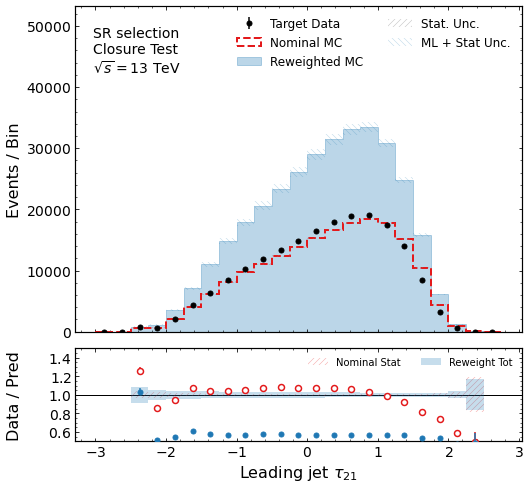


Generating closure plot for feature: ljet1_tau32
Metrics for ljet1_tau32 in SR:
  Nominal MC -> chi2/ndf: 1623.85/19 (p=0.0000) | Norm W1: 0.0904
  Reweighted -> chi2/ndf: 2686.58/19 (p=0.0000) | Norm W1: 0.0212
----------------------------------------------------------------------


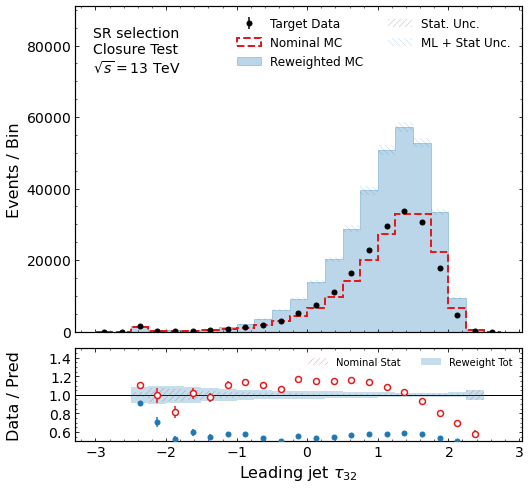


Generating closure plot for feature: ljet2_tau21
Metrics for ljet2_tau21 in SR:
  Nominal MC -> chi2/ndf: 878.83/19 (p=0.0000) | Norm W1: 0.0559
  Reweighted -> chi2/ndf: 3608.46/19 (p=0.0000) | Norm W1: 0.0087
----------------------------------------------------------------------


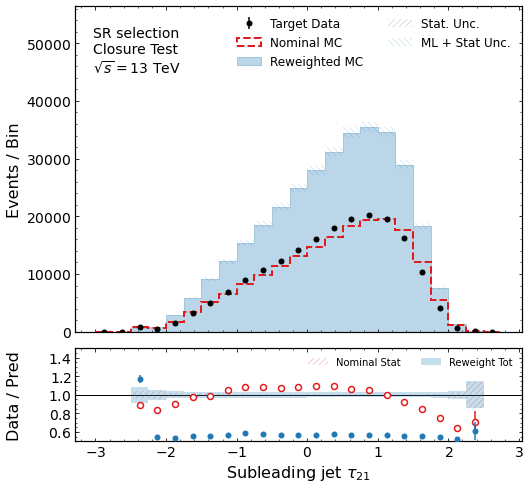


Generating closure plot for feature: ljet2_tau32
Metrics for ljet2_tau32 in SR:
  Nominal MC -> chi2/ndf: 1386.33/19 (p=0.0000) | Norm W1: 0.0765
  Reweighted -> chi2/ndf: 1989.38/19 (p=0.0000) | Norm W1: 0.0545
----------------------------------------------------------------------


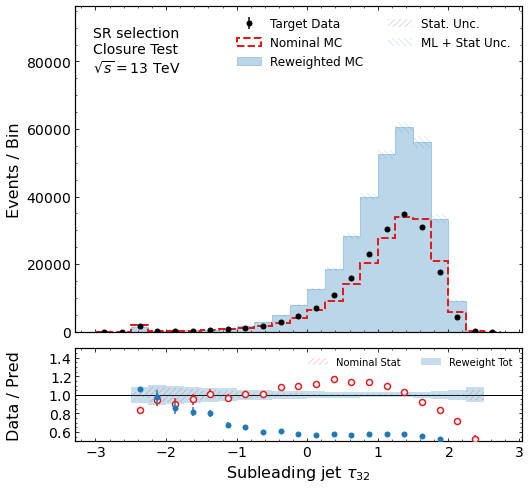

In [16]:
df_data_sr = pl.from_pandas(data_sr)
df_mc_sr = pl.from_pandas(mc_sr)

for feature in features_to_train:
    print(f"\nGenerating closure plot for feature: {feature}")
    plot_closure("SR", df_mc_sr, df_data_sr, feature)